<a href="https://colab.research.google.com/github/evgenia-18/ICS-493633/blob/main/Lab9_2_%D0%93%D0%BB%D1%83%D1%88%D0%B0%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Була присутня на парі

In [8]:
!pip install kneed --quiet

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import seaborn as sns

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler


In [13]:
from google.colab import files
uploaded = files.upload()

Saving Leukemia_GSE9476.csv.zip to Leukemia_GSE9476.csv.zip


In [14]:
df = pd.read_csv('Leukemia_GSE9476.csv.zip')

df

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,...,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,...,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,...,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,...,4.633334,6.375991,12.903630,12.871454,5.179951,4.641952,3.991634,3.704587,4.149938,3.910150
4,15,Bone_Marrow_CD34,8.010117,7.405281,6.656049,9.050682,4.514986,8.377046,5.493713,4.860754,...,5.305192,6.700453,12.949352,12.782515,5.341689,4.560315,3.887020,3.629853,4.127513,4.004316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,60,PBSC_CD34,7.686106,6.856961,6.822222,8.849700,4.440703,8.456949,5.408897,4.708615,...,4.969400,7.016576,12.997293,12.828832,5.084120,4.531087,3.884230,3.619301,4.108490,4.070028
60,61,PBSC_CD34,7.816168,6.875124,6.532324,8.827857,4.515457,8.450286,5.482797,4.667874,...,4.826255,6.577223,12.990305,12.855352,5.260451,4.568651,3.927693,3.634879,4.112277,4.064780
61,62,PBSC_CD34,7.863092,6.896242,6.630690,8.775139,4.458048,8.664517,5.577298,4.853996,...,5.065816,6.583261,12.786121,12.588852,5.451940,4.739944,4.010427,3.668713,4.162220,4.102264
62,63,PBSC_CD34,7.900992,6.787515,6.642927,8.856187,4.499548,9.188459,5.471110,4.637444,...,4.985061,6.815527,13.020089,12.824868,5.459571,4.602105,4.019624,3.570563,4.141371,4.102641


In [15]:
target = df["type"]
target.value_counts()

,count
type,
AML,26
PB,10
Bone_Marrow,10
PBSC_CD34,10
Bone_Marrow_CD34,8


In [16]:
X = df.drop (columns=['samples','type'])

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# масштабирование
x = StandardScaler().fit_transform(X)

# PCA
pca = PCA(random_state=42).fit(X)

# доля объяснённой дисперсии
pve = pca.explained_variance_ratio_

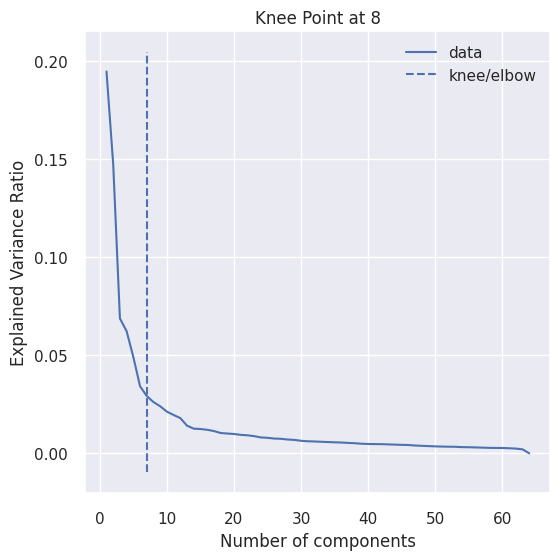

In [22]:
sns.set_theme()

kneedle = KneeLocator(
    x=range(1, len(pve) + 1),
    y=pve,
    curve='convex',
    direction='decreasing'
)

# Візуалізація
kneedle.plot_knee()
plt.title(f'Knee Point at {kneedle.elbow + 1}')
plt.xlabel("Number of components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

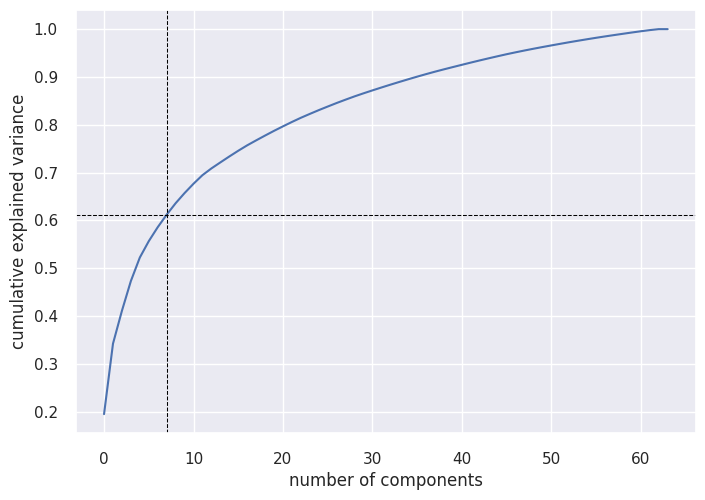

In [23]:
n_components = kneedle.elbow

ax = sns.lineplot(np.cumsum(pve))

ax.axvline(x=n_components,
     c='black',
     linestyle='--',
     linewidth=0.75)

ax.axhline(y=np.cumsum(pve)[n_components],
     c='black',
     linestyle='--',
     linewidth=0.75)

ax.set(xlabel='number of components',
   ylabel='cumulative explained variance')

plt.show()

In [25]:
x = pca.transform(x)[:, :n_components]

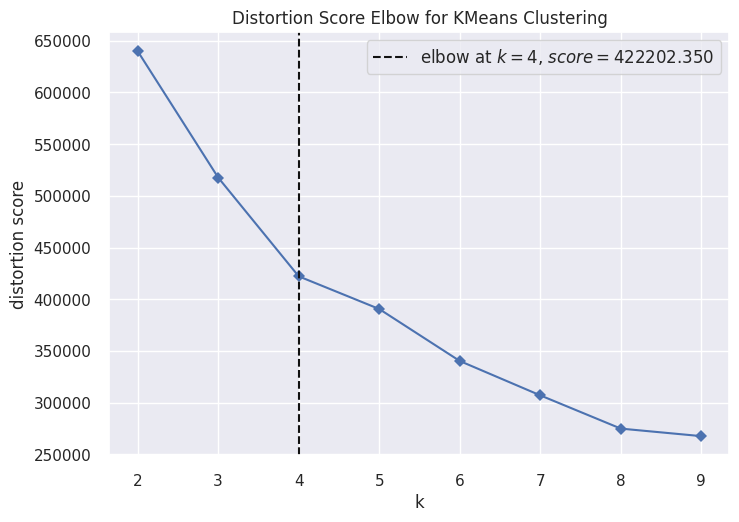

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [26]:
model_kmn = KMeans(random_state=42)
visualizer = KElbowVisualizer(
    model_kmn,
    k= (2, 10),
    timings=False)

visualizer.fit(x)
visualizer.show()

In [27]:
def plot_dendrogram(model, **kwargs):

    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)


In [28]:
model_agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None)

model_agg = model_agg.fit(X)

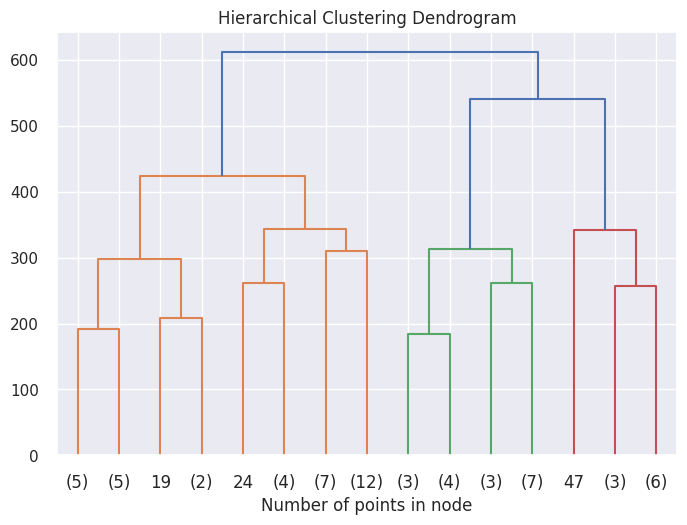

In [29]:
plot_dendrogram(model_agg, truncate_mode='level', p=3)
plt.title('Hierarchical Clustering Dendrogram' )
plt.xlabel('Number of points in node')

plt.show()

In [30]:
k_best = visualizer.elbow_value_

model_kmn = KMeans(n_clusters=k_best, random_state=42).fit(X)
model_agg = AgglomerativeClustering(n_clusters=k_best).fit(X)

labels_kmn = pd.Series(model_kmn.labels_, name='k-means')
labels_agg = pd.Series(model_agg.labels_, name='h-clust')

In [31]:
pd.crosstab(df['type'], labels_kmn)

k-means,0,1,2,3
type,,,,
AML,9,8,9,0
Bone_Marrow,0,0,10,0
Bone_Marrow_CD34,1,7,0,0
PB,0,0,0,10
PBSC_CD34,0,10,0,0


In [32]:
pd.crosstab(df['type'], labels_agg)

h-clust,0,1,2,3
type,,,,
AML,7,0,16,3
Bone_Marrow,0,0,0,10
Bone_Marrow_CD34,7,0,1,0
PB,0,10,0,0
PBSC_CD34,10,0,0,0


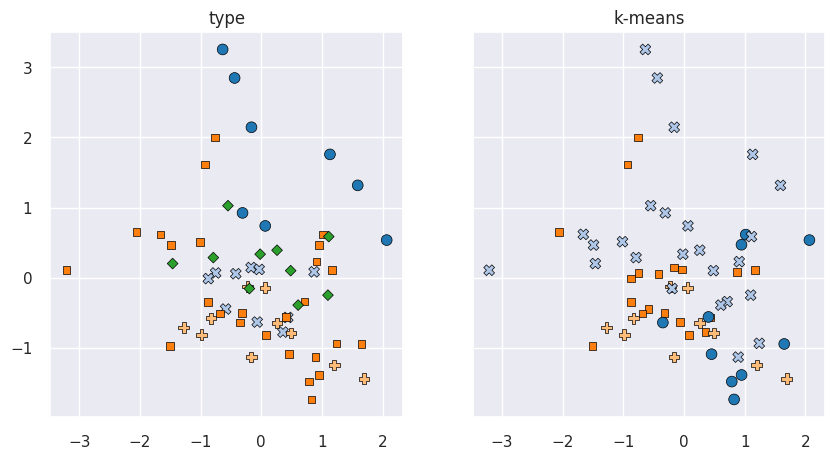

In [33]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10, 5),sharey=True)

for i, s in enumerate([df['type'], labels_kmn]):
    ax = axes[i]

    sns.scatterplot(x=X[:, 0],
            y=X[:, 1],
            hue=s,
            style=s,
            edgecolor='black',
            linewidth=0.5,
            s=60,
            palette='tab20',
            legend=False,
            ax=ax)

    ax.set(title=s.name)

plt.show()

Висновки- у лабораторній роботі ми провели кластерізацю диних з використанням різних методів.Та вони показали різницю між ними